In [24]:
import random
import numpy as np
import matplotlib.pyplot as plt
import os


In [25]:
data_path = r"/content/drive/MyDrive/CV_Programming_1/Part_2/A/510_cluster_dataset.txt"

In [26]:
K_values = [2, 3, 4]  # For part 1
R_iterations = 3  # random center iterations
A_iterations = 1  # adjust center iterations
colors = ['r', 'g', 'b', 'm', 'c', 'k', 'y', 'b', 'g', 'r', 'c']

In [27]:
def create_random_centers(points, clusters):
    indexes = random.sample(range(len(points)), clusters)
    return [points[i][0] for i in indexes]

In [28]:
def calculate_distance(point1, point2):
    return np.linalg.norm(np.array(point1) - np.array(point2))

In [29]:
def assign_center(points, centers):
    for point in points:
        min_distance = float('inf')
        for j, center in enumerate(centers):
            distance = calculate_distance(point[0], center)
            if distance < min_distance:
                min_distance = distance
                point[1] = j

In [30]:
def adjust_centers(points, clusters):
    new_centers = []
    for cluster in range(clusters):
        cluster_points = np.array([point[0] for point in points if point[1] == cluster])
        new_center = np.mean(cluster_points, axis=0)
        new_centers.append(new_center)
    return new_centers

In [31]:
def calculate_square_error(points, centers):
    total_error = 0
    for point in points:
        center = centers[point[1]]
        total_error += calculate_distance(point[0], center)
    return total_error

In [32]:
def plot_clusters(points, centers, square_error, r_iteration, a_iteration, clusters):
    plt.figure(figsize=(8, 6))
    for cluster in range(clusters):
        cluster_points = np.array([point[0] for point in points if point[1] == cluster])
        plt.scatter(cluster_points[:, 0], cluster_points[:, 1], s=30, c=colors[cluster], label=f'Cluster {cluster}')
    centers_np = np.array(centers)
    plt.scatter(centers_np[:, 0], centers_np[:, 1], s=300, marker='X', c='black', label='Centers')
    title = f"K{clusters}_R{r_iteration}_A{a_iteration}_SSE {round(square_error, 2)}"
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [33]:
def kmeans(points, clusters):
    # Convert points to a structured array with dtype object
    points = np.array(points, dtype=object)
    lowest_error = float('inf')
    best_centers = None

    for r_iteration in range(R_iterations):
        centers = create_random_centers(points, clusters)
        assign_center(points, centers)

        for a_iteration in range(A_iterations):
            centers = adjust_centers(points, clusters)
            assign_center(points, centers)
            current_error = calculate_square_error(points, centers)

            # Plotting for visualization of each iteration
            plot_clusters(points, centers, current_error, r_iteration, a_iteration, clusters)

            if current_error < lowest_error:
                lowest_error = current_error
                best_centers = centers

    print(f"Lowest square error for K={clusters} is {round(lowest_error, 2)} with centers:")
    for center in best_centers:
        print(center)

In [34]:
points = []
with open(data_path, 'r') as file:
    for line in file:
        coordinates = list(map(float, line.split()))
        points.append([[coordinates[0], coordinates[1]], 0])

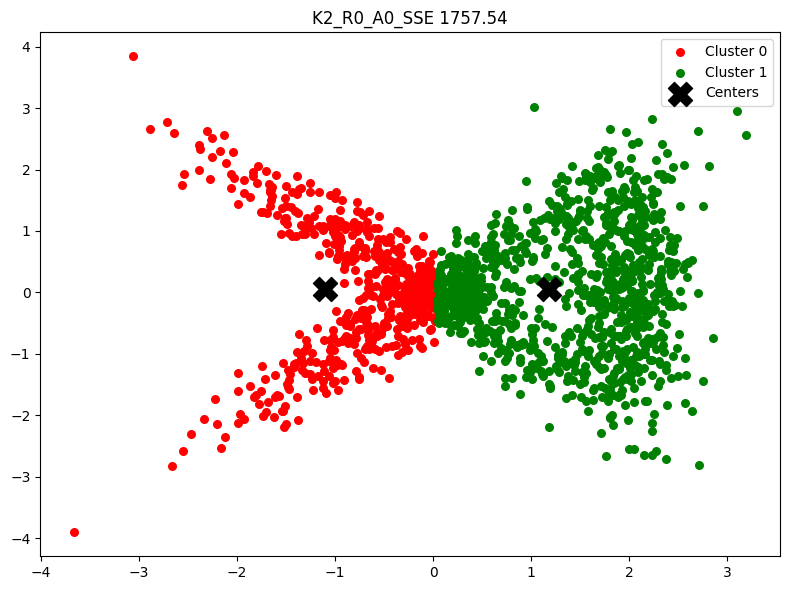

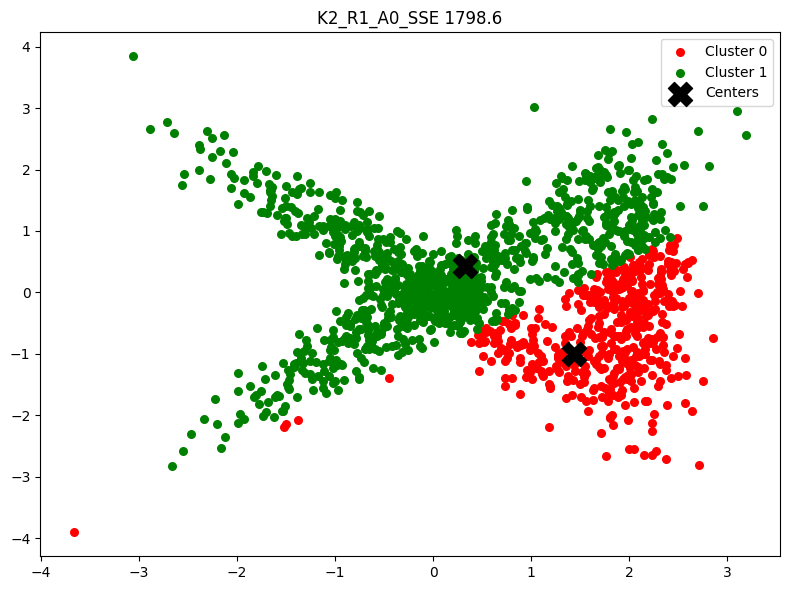

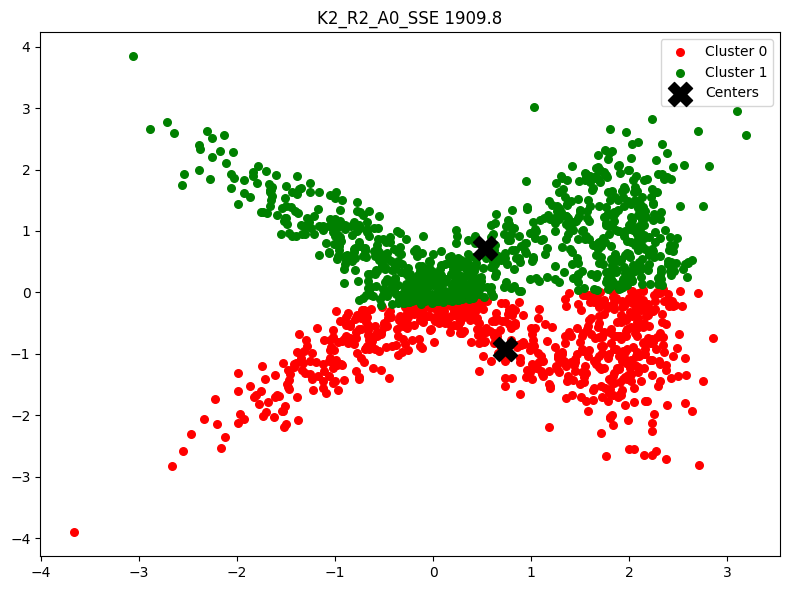

Lowest square error for K=2 is 1757.54 with centers:
[-1.09831474  0.0538094 ]
[1.18140035 0.05669209]


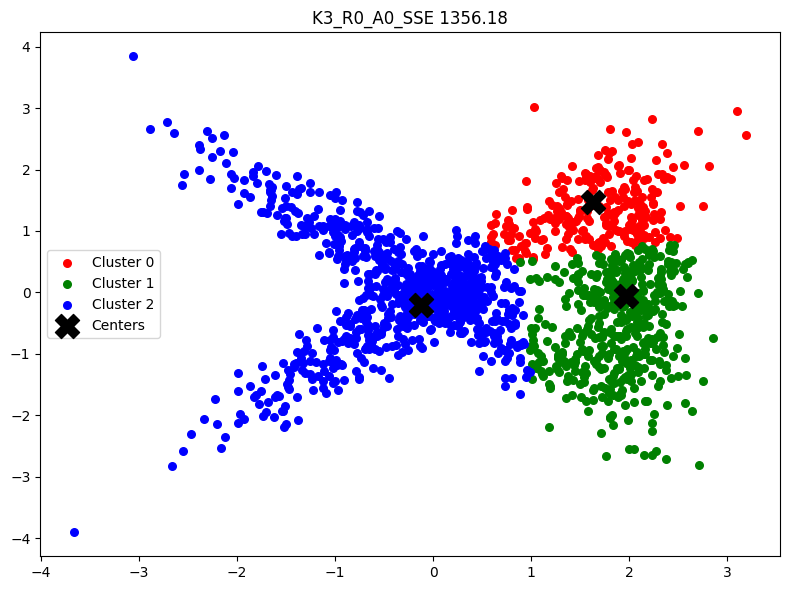

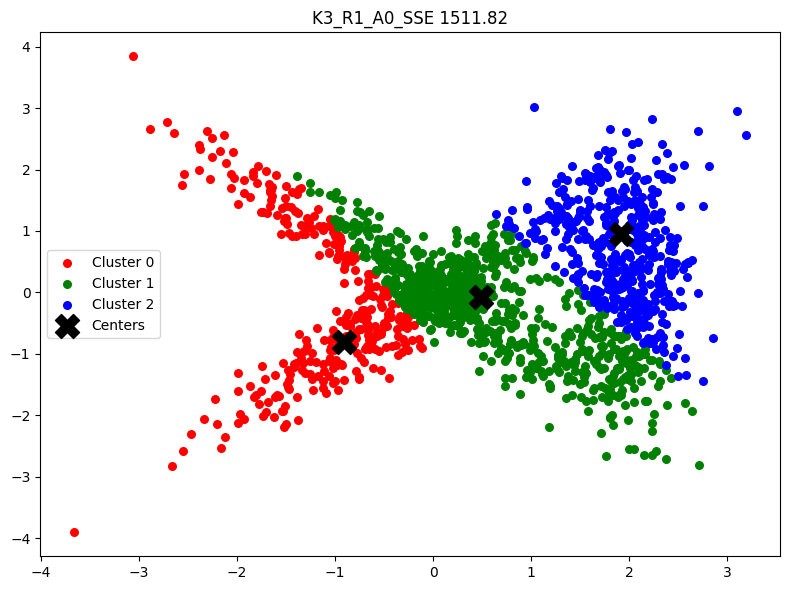

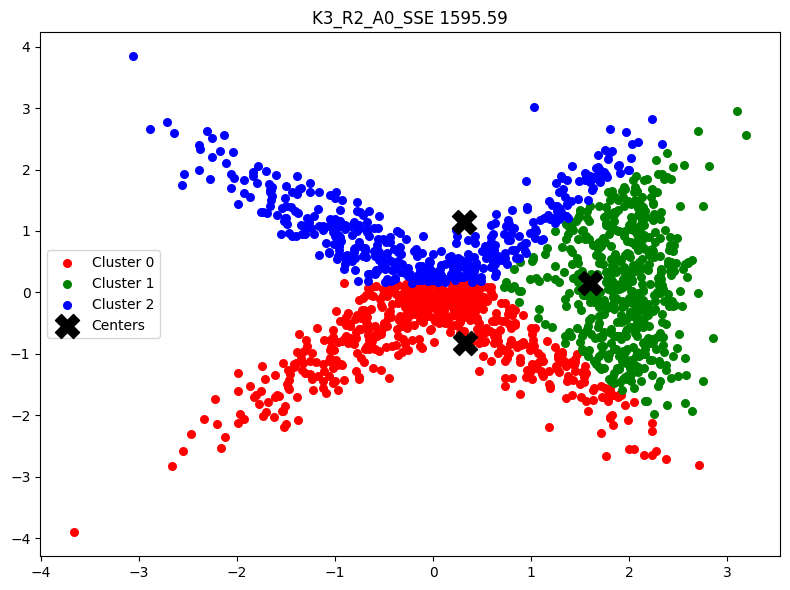

Lowest square error for K=3 is 1356.18 with centers:
[1.6290945  1.47546322]
[ 1.96805329 -0.06576655]
[-0.1257605 -0.213163 ]


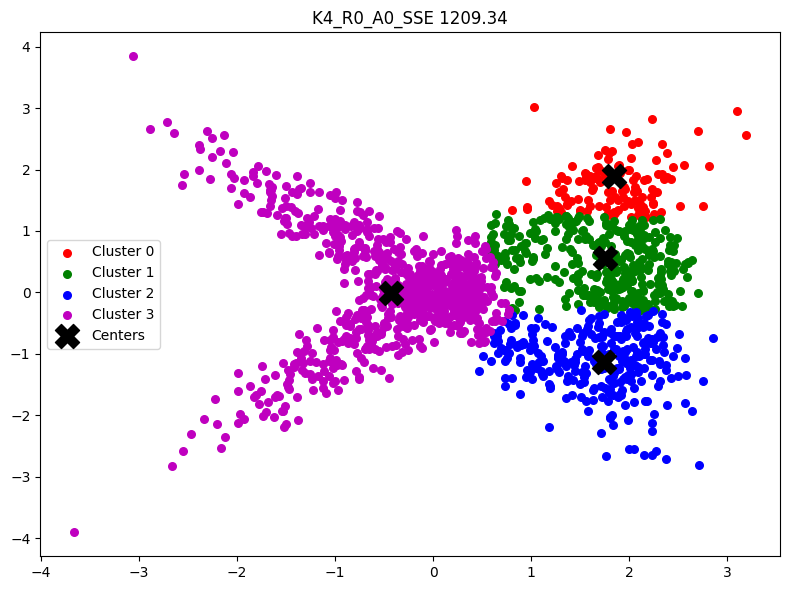

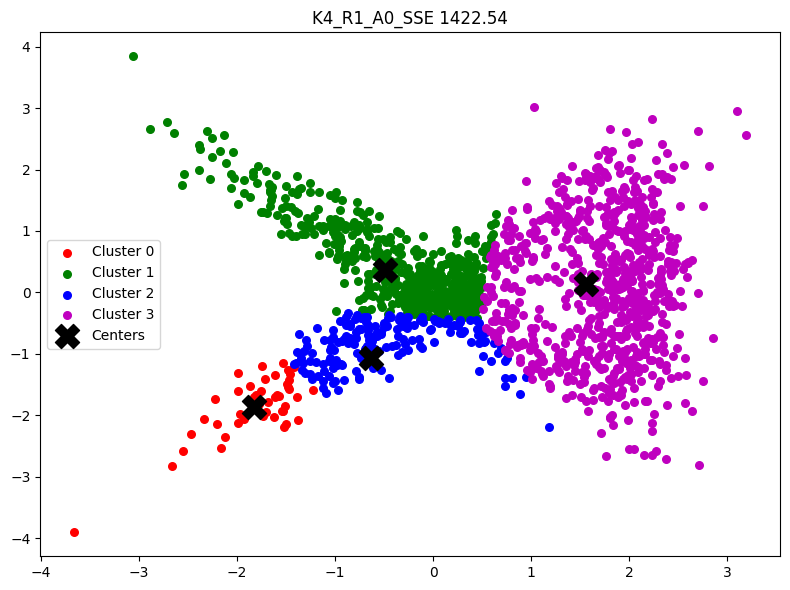

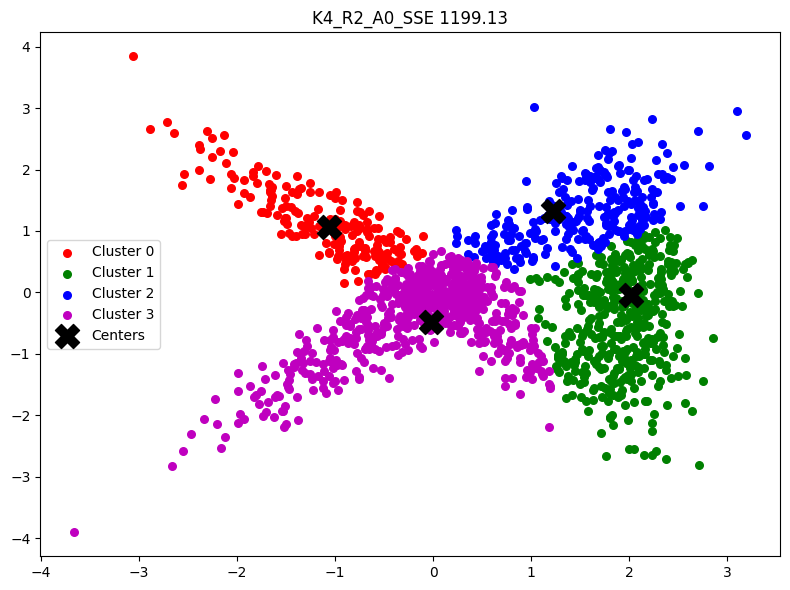

Lowest square error for K=4 is 1199.13 with centers:
[-1.06348683  1.06557964]
[ 2.02135774 -0.04522105]
[1.22777049 1.31993648]
[-0.02234131 -0.47636662]


In [35]:
for clusters in K_values:
    kmeans(points, clusters)